In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [30]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

Note: you may need to restart the kernel to use updated packages.


In [31]:
import dagshub

dagshub.init(repo_owner='lmars23', repo_name='ml_assignment_2', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=700dd3e9-1de6-4cf8-904d-c7cde10275b3&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=e19b1103e7b345f4cb9bec277b76ca102eed59c583a6e1ab2fb8e48a437e53c1




Accessing as lmars23

Initialized MLflow to track repo "lmars23/ml_assignment_2"

Repository lmars23/ml_assignment_2 initialized!

In [2]:
import pandas as pd
import gc

def reduce_memory_usage(df):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object and str(col_type) != "category":
            try:
                c_min = df[col].min()
                c_max = df[col].max()

                if str(col_type)[:3] == "int":
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    else:
                        df[col] = df[col].astype(np.int64)

                else:
                    if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)

            except:
                pass

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    reduction = 100 * (start_mem - end_mem) / start_mem

    print(f"Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB ({reduction:.1f}% reduction)")

    return df

train_tr = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_id = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

train_tr = reduce_memory_usage(train_tr)
train_id = reduce_memory_usage(train_id)

gc.collect()

Memory usage: 2062.07 MB -> 2062.07 MB (0.0% reduction)
Memory usage: 143.14 MB -> 143.14 MB (0.0% reduction)


0

In [3]:
print(train_tr.shape)
print(train_id.shape)

(590540, 394)
(144233, 41)


In [4]:
train_tr.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
train_id.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [6]:
train = train_tr.merge(train_id, on='TransactionID', how='left')
train = reduce_memory_usage(train)

del train_tr
del train_id
gc.collect()

Memory usage: 2513.97 MB -> 2513.97 MB (0.0% reduction)


0

In [7]:
train['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split

X = train.drop(['isFraud', 'TransactionID'], axis=1)
y = train['isFraud']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train = reduce_memory_usage(X_train)
X_val = reduce_memory_usage(X_val)

del X
gc.collect()


Memory usage: 2007.64 MB -> 2007.64 MB (0.0% reduction)
Memory usage: 501.82 MB -> 501.82 MB (0.0% reduction)


0

In [9]:
X_train.head()

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
40809,1008491,100.00,R,6177,399.0,150.0,american express,150.0,credit,264.0,...,ie 11.0 for desktop,24.0,1920x1080,match_status:2,T,F,T,T,desktop,Trident/7.0
285886,7008212,29.99,W,7900,345.0,150.0,mastercard,224.0,debit,143.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104256,2071522,107.95,W,11690,111.0,150.0,visa,226.0,credit,191.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
507860,13299752,241.95,W,2616,327.0,150.0,discover,102.0,credit,330.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196382,4412283,117.00,W,13780,298.0,150.0,visa,226.0,debit,441.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# EDA

In [10]:
df = X_train.copy()
df['isFraud'] = y_train

In [11]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.965011
1    0.034989
Name: proportion, dtype: float64

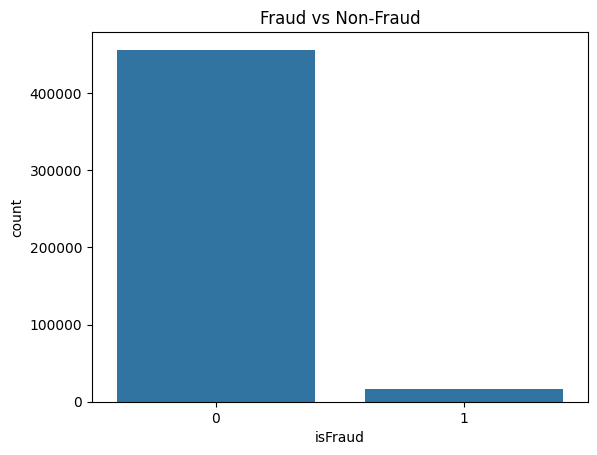

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

In [44]:
train_missing = X_train.isnull().mean().sort_values(ascending=False)
train_missing.head(20)

id_24    0.991971
id_25    0.991317
id_07    0.991292
id_08    0.991292
id_21    0.991281
id_26    0.991275
id_23    0.991266
id_27    0.991266
id_22    0.991266
dist2    0.936169
D7       0.934003
id_18    0.923536
D13      0.894715
D14      0.894283
D12      0.890031
id_03    0.887408
id_04    0.887408
D6       0.875631
id_33    0.875559
id_10    0.872725
dtype: float64

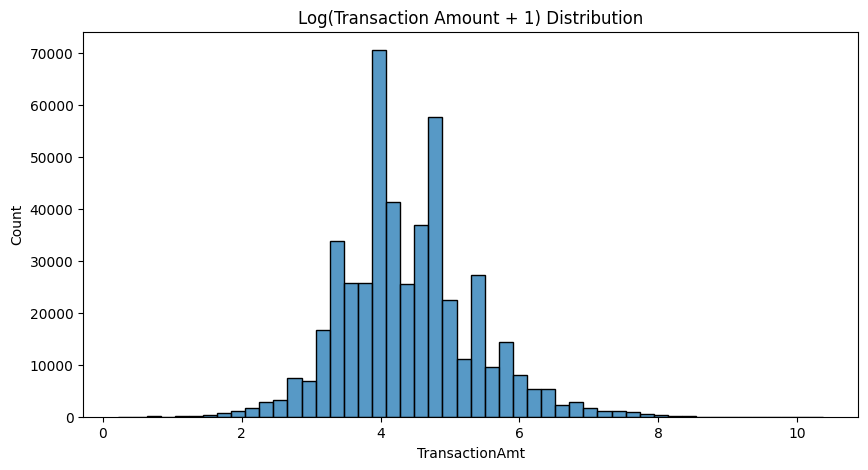

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(X_train['TransactionAmt']), bins=50)
plt.title("Log(Transaction Amount + 1) Distribution")
plt.show()

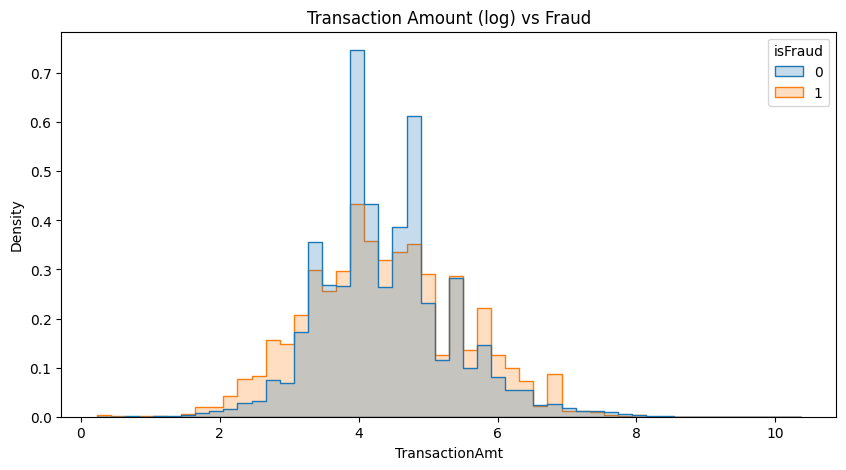

In [46]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=X_train.assign(isFraud=y_train),
    x=np.log1p(X_train['TransactionAmt']),
    hue=y_train,
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount (log) vs Fraud")
plt.show()

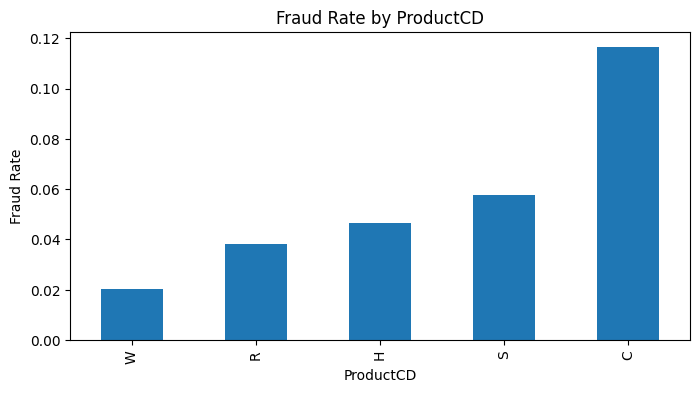

In [47]:
fraud_rate = df.groupby('ProductCD')['isFraud'].mean().sort_values()

fraud_rate.plot(kind='bar', figsize=(8,4))
plt.title("Fraud Rate by ProductCD")
plt.ylabel("Fraud Rate")
plt.show()

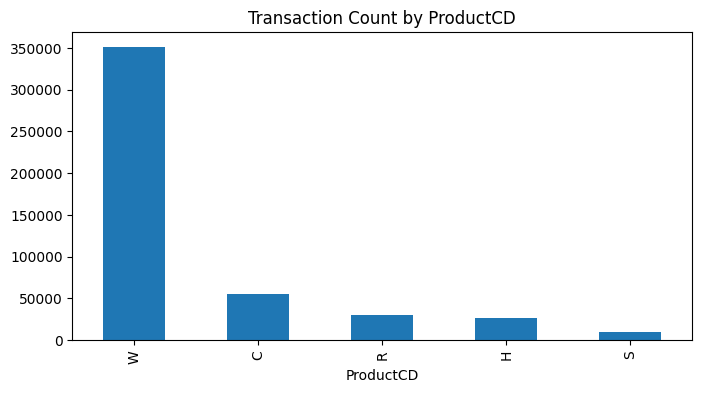

In [48]:
df['ProductCD'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title("Transaction Count by ProductCD")
plt.show()

In [49]:
df['P_emaildomain'] = df['P_emaildomain'].fillna("missing")

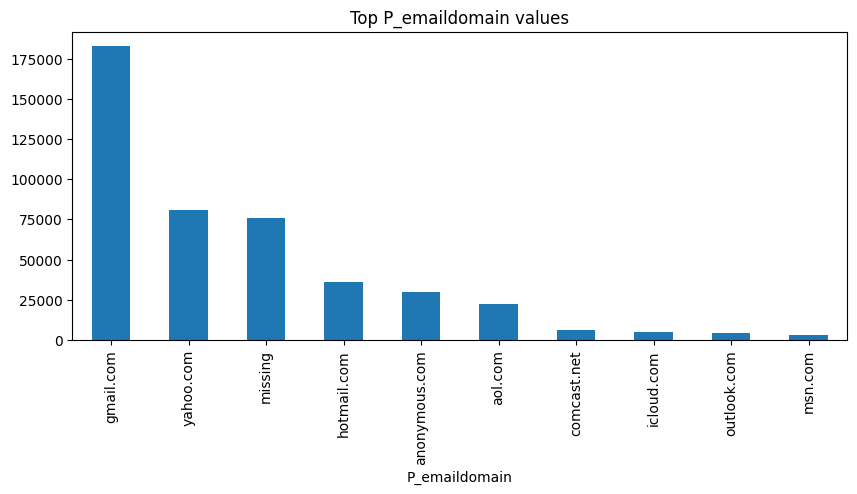

In [50]:
top_domains = df['P_emaildomain'].value_counts().head(10)
top_domains.plot(kind='bar', figsize=(10,4))
plt.title("Top P_emaildomain values")
plt.show()

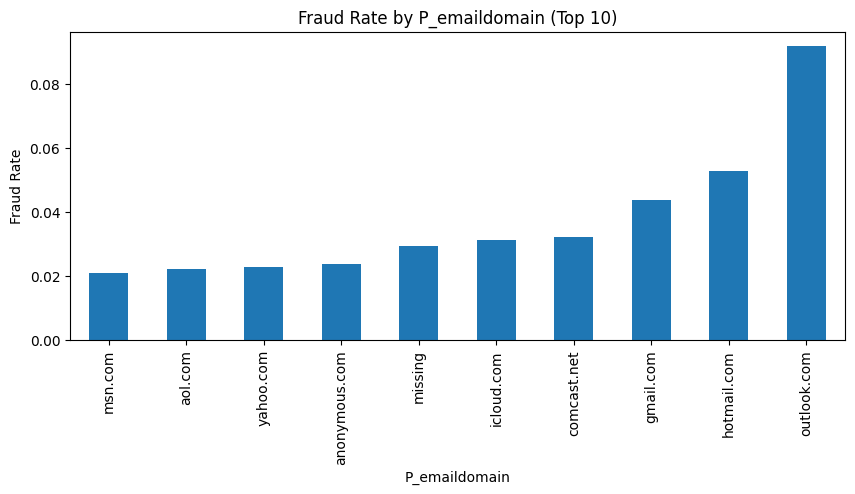

In [51]:
top = df['P_emaildomain'].value_counts().head(10).index
subset = df[df['P_emaildomain'].isin(top)]

fraud_rate = subset.groupby('P_emaildomain')['isFraud'].mean().sort_values()

fraud_rate.plot(kind='bar', figsize=(10,4))
plt.title("Fraud Rate by P_emaildomain (Top 10)")
plt.ylabel("Fraud Rate")
plt.show()

In [52]:
df['R_emaildomain'] = df['R_emaildomain'].fillna("missing")

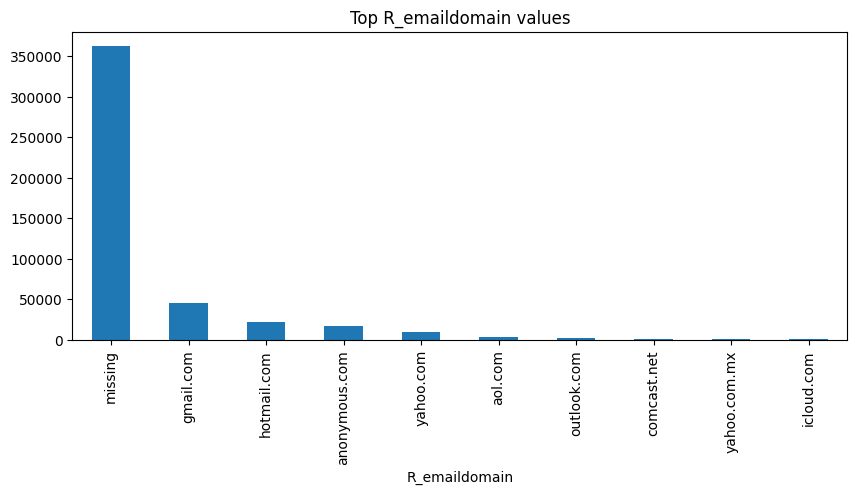

In [53]:
df['R_emaildomain'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,4),
    title="Top R_emaildomain values"
)
plt.show()

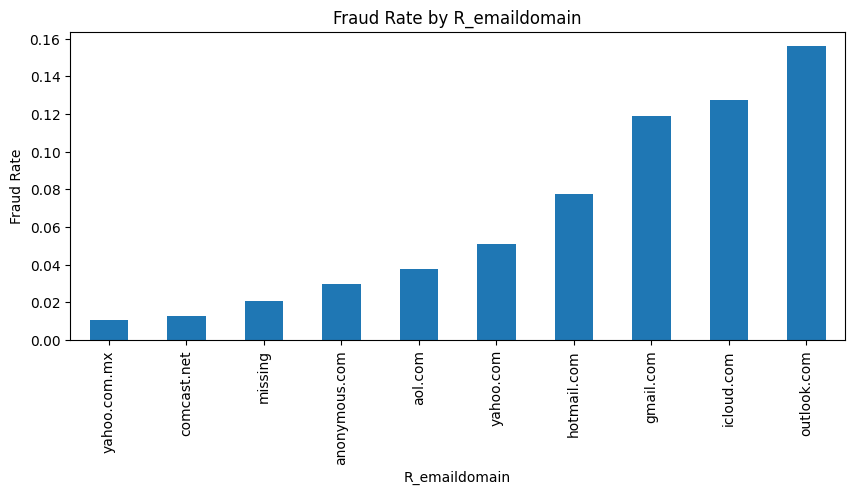

In [54]:
top = df['R_emaildomain'].value_counts().head(10).index
subset = df[df['R_emaildomain'].isin(top)]

fraud_rate = subset.groupby('R_emaildomain')['isFraud'].mean().sort_values()

fraud_rate.plot(kind='bar', figsize=(10,4))
plt.title("Fraud Rate by R_emaildomain")
plt.ylabel("Fraud Rate")
plt.show()

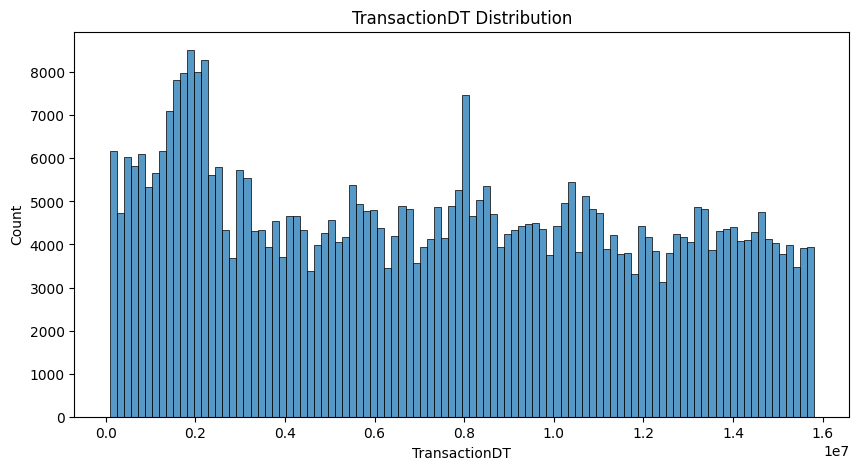

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(X_train['TransactionDT'], bins=100)
plt.title("TransactionDT Distribution")
plt.show()

<Axes: xlabel='day'>

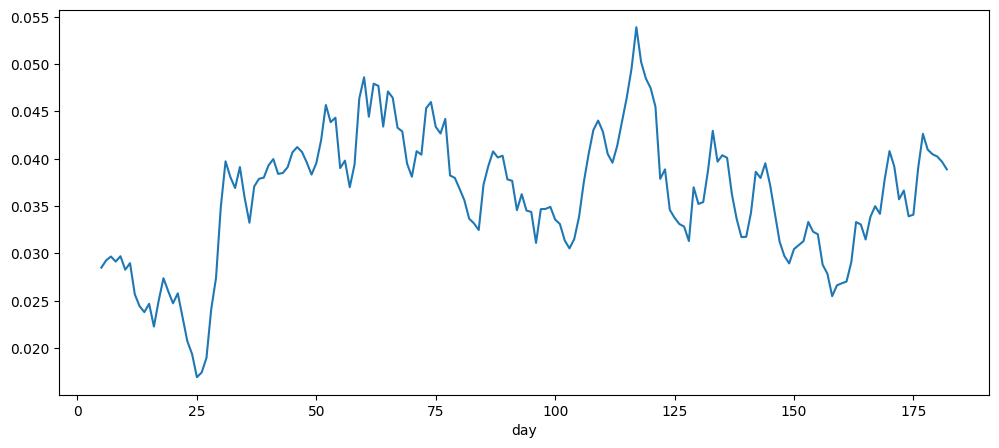

In [56]:
df['day'] = df['TransactionDT'] // (3600 * 24)

fraud_by_day = df.groupby('day')['isFraud'].mean()

fraud_by_day.rolling(5).mean().plot(figsize=(12,5))

In [57]:
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day'] = df['TransactionDT'] // (3600 * 24)

df['weekday'] = df['day'] % 7

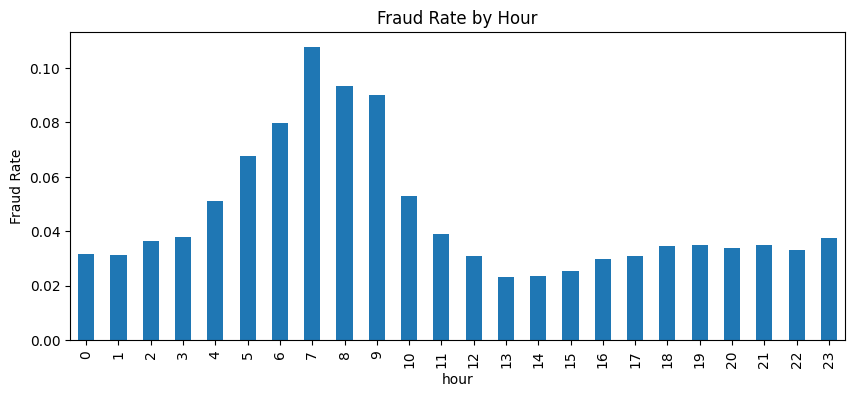

In [58]:
import matplotlib.pyplot as plt

df.groupby('hour')['isFraud'].mean().plot(kind='bar', figsize=(10,4))
plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Rate")
plt.show()

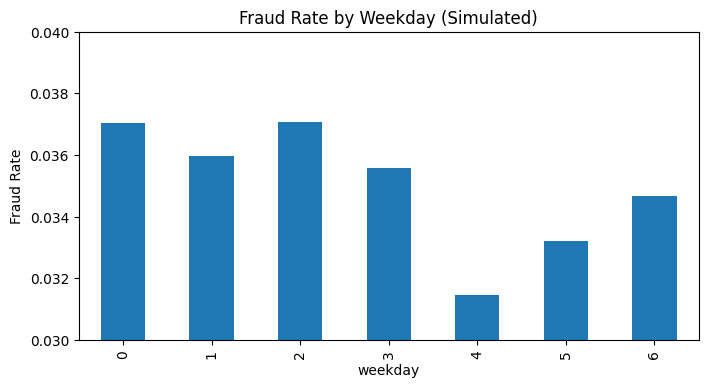

In [59]:
df.groupby('weekday')['isFraud'].mean().plot(kind='bar', figsize=(8,4))
plt.ylim(0.03, 0.04)
plt.title("Fraud Rate by Weekday (Simulated)")
plt.ylabel("Fraud Rate")
plt.show()

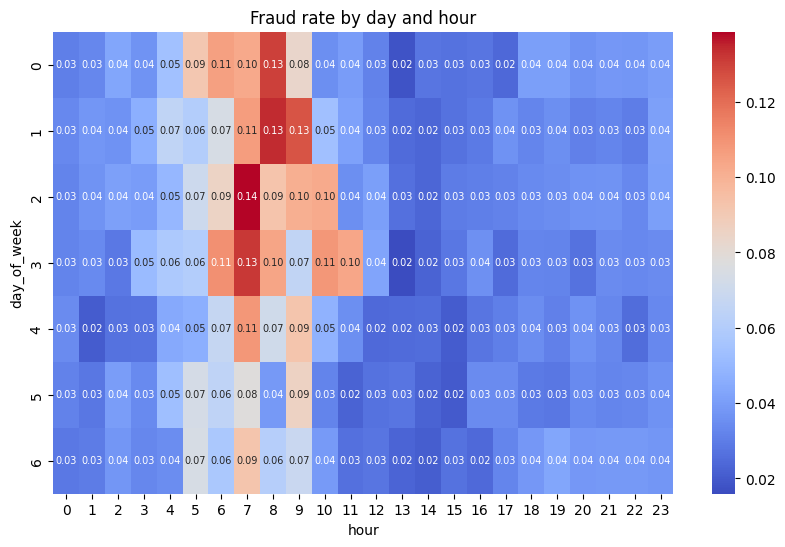

In [60]:
df['day_of_week'] = (df['TransactionDT'] // (3600*24)) % 7

pivot = df.pivot_table(
    values='isFraud',
    index='day_of_week',
    columns='hour',
    aggfunc='mean'
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot.reindex(index=range(7)),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7} 
)

plt.title("Fraud rate by day and hour")
plt.show()

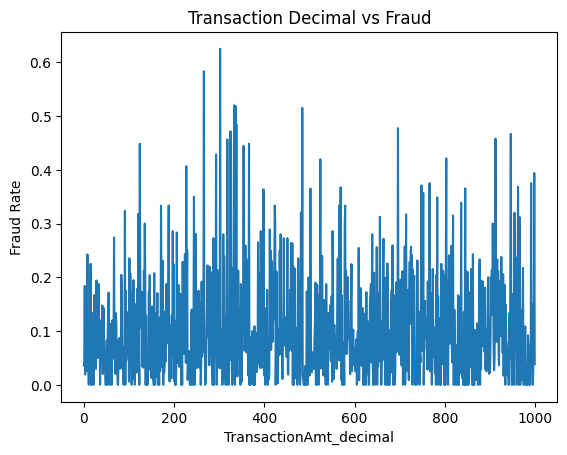

In [13]:
import matplotlib.pyplot as plt

df["TransactionAmt_decimal"] = ((df["TransactionAmt"] % 1) * 1000).round()

fraud_rate = df.groupby("TransactionAmt_decimal")["isFraud"].mean()

plt.figure()
plt.plot(fraud_rate.index, fraud_rate.values)
plt.xlabel("TransactionAmt_decimal")
plt.ylabel("Fraud Rate")
plt.title("Transaction Decimal vs Fraud")
plt.show()